Model Summary:


C:\Users\23adsb68\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 200, 128)            │       1,280,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn (SimpleRNN)               │ (None, 64)                  │          12,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,292,417 (4.93 MB)

 Trainable params: 1,292,417 (4.93 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 24s 144ms/step - accuracy: 0.5278 - loss: 0.6913 - precision: 0.5298 - recall: 0.5198 - val_accuracy: 0.5794 - val_loss: 0.6720 - val_precision: 0.6583 - val_recall: 0.3082
Epoch 2/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 37s 119ms/step - accuracy: 0.7301 - loss: 0.5670 - precision: 0.7336 - recall: 0.7252 - val_accuracy: 0.7554 - val_loss: 0.5325 - val_precision: 0.6886 - val_recall: 0.9214
Epoch 3/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 20s 119ms/step - accuracy: 0.8349 - loss: 0.4131 - precision: 0.8293 - recall: 0.8448 - val_accuracy: 0.8438 - val_loss: 0.3938 - val_precision: 0.8468 - val_recall: 0.8348
Epoch 4/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 25s 144ms/step - accuracy: 0.8814 - loss: 0.3206 - precision: 0.8796 - recall: 0.8846 - val_accuracy: 0.8502 - val_loss: 0.3699 - val_precision: 0.8285 - val_recall: 0.8785
Epoch 5/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 21s 135ms/step - accuracy: 0.9042 - loss: 0.2628 - precision: 0.9055 - recall: 0.9033 - val_accuracy: 0.8598

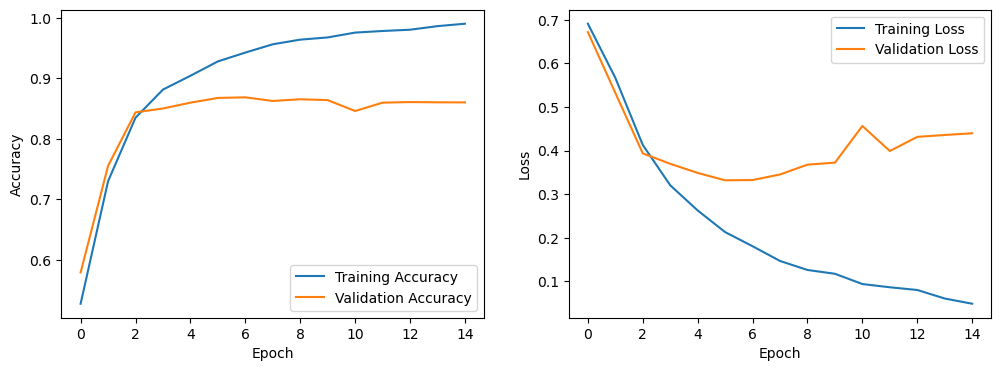

782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.8422 - loss: 0.4871 - precision: 0.8431 - recall: 0.8410
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step

Final Test Accuracy: 84.22%
Final Test Loss: 0.4871
Final Test Precision: 0.8431
Final Test Recall: 0.8410
Final Test F1 Score: 0.8420


In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from tensorflow.keras.metrics import Precision, Recall, BinaryAccuracy
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import f1_score

# 1. Data Loading & Preprocessing
vocab_size = 10000
maxlen = 200
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)
X_train = pad_sequences(X_train, maxlen=maxlen)
X_test = pad_sequences(X_test, maxlen=maxlen)

# 2. Model Building
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=128, input_length=maxlen),
    SimpleRNN(64, return_sequences=False),
    Dense(1, activation='sigmoid')
])

# Build the model by passing a batch of data
model.build(input_shape=(None, maxlen))

# 3. Compilation & Training
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=[
        BinaryAccuracy(name='accuracy'),
        Precision(name='precision'),
        Recall(name='recall')
    ]
)

print("Model Summary:")
model.summary()

# Train for 15 epochs
history = model.fit(
    X_train, y_train,
    batch_size=128,
    epochs=15,
    validation_split=0.2
)

# 4. Plots
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.savefig('training_history.png')
plt.show()

# 5. Final Evaluation
test_loss, test_acc, test_precision, test_recall = model.evaluate(X_test, y_test)
y_pred = (model.predict(X_test) > 0.5).astype("int32")
f1 = f1_score(y_test, y_pred)

print(f"\nFinal Test Accuracy: {test_acc*100:.2f}%")
print(f"Final Test Loss: {test_loss:.4f}")
print(f"Final Test Precision: {test_precision:.4f}")
print(f"Final Test Recall: {test_recall:.4f}")
print(f"Final Test F1 Score: {f1:.4f}")
